In [79]:
from sklearn.datasets import make_moons
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [23]:
x,y=make_moons(n_samples=1000,noise=0.03,random_state=18)

In [24]:
df=pd.DataFrame({"x1":x[:,0],"x2":x[:,1],"label":y})
df["label"].value_counts()

label
0    500
1    500
Name: count, dtype: int64

In [25]:
x=torch.from_numpy(x).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

<Axes: xlabel='None', ylabel='None'>

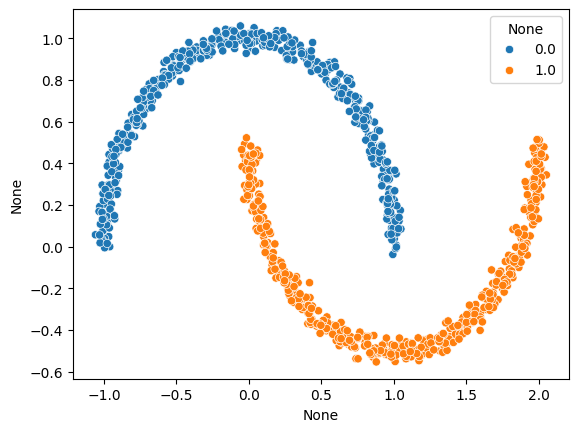

In [26]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=y)

In [28]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=18)

In [73]:
class classifier(nn.Module):
    def __init__(self,input_features,output_features,hidden_units):
        super().__init__()
        self.layerstack=nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features)
        )

    def forward(self,x):
        return self.layerstack(x)
    

In [74]:
model=classifier(2,1,8)
model

classifier(
  (layerstack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [75]:
loss_func=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [76]:
epochs=10000
for epoch in range(epochs):
    model.train()
    y_logit=model(x_train).squeeze()
    loss=loss_func(y_logit,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        y_test_logit=model(x_test).squeeze()
        y_test_pred=torch.round(torch.sigmoid(y_test_logit))
        test_loss=loss_func(y_test_logit,y_test)

        if epoch%1000==0:
            print(f"At epoch {epoch} accuracy is {accuracy_score(y_test,y_test_pred)} and loss is {test_loss}")
            

At epoch 0 accuracy is 0.5 and loss is 0.68914794921875
At epoch 1000 accuracy is 0.855 and loss is 0.5525739789009094
At epoch 2000 accuracy is 0.895 and loss is 0.22995756566524506
At epoch 3000 accuracy is 0.94 and loss is 0.16919372975826263
At epoch 4000 accuracy is 0.99 and loss is 0.06872086971998215
At epoch 5000 accuracy is 1.0 and loss is 0.02556706592440605
At epoch 6000 accuracy is 1.0 and loss is 0.012798404321074486
At epoch 7000 accuracy is 1.0 and loss is 0.007891815155744553
At epoch 8000 accuracy is 1.0 and loss is 0.005474450066685677
At epoch 9000 accuracy is 1.0 and loss is 0.004096364602446556


In [69]:
from helper_functions import plot_decision_boundary

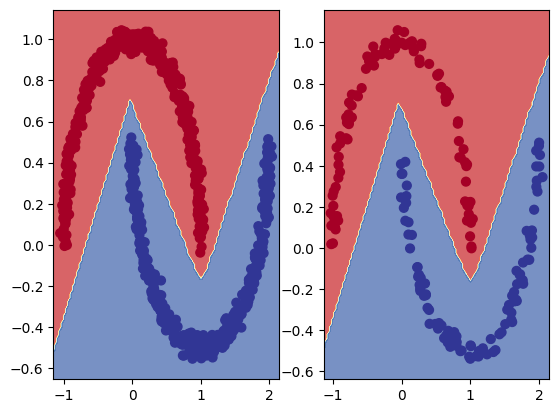

In [77]:
plt.subplot(1,2,1)
plot_decision_boundary(model,x_train,y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model,x_test,y_test)

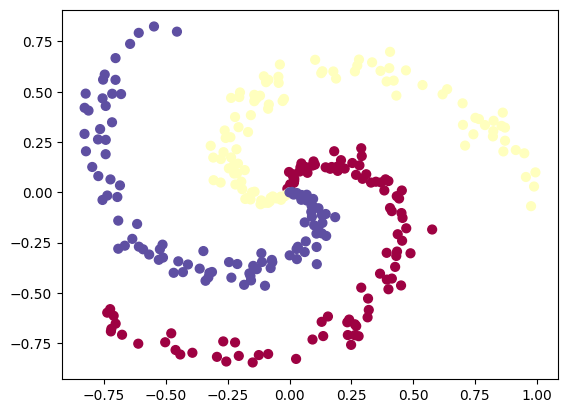

In [113]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [114]:
len(X),len(y)

(300, 300)

In [115]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [116]:
x_train,x_test,y_train,y_test=tts(X,y,test_size=0.2,random_state=18)

In [119]:
y_train = y_train.long()
y_test = y_test.long()

In [142]:
class multi_classifier(nn.Module):
    def __init__(self,input_features,output_features,hidden_units):
        super().__init__()
        self.layerstack=nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            nn.Tanh(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features)
        )

    def forward(self,x):
        return self.layerstack(x)

In [147]:
model1=multi_classifier(2,3,8)
model1

multi_classifier(
  (layerstack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [148]:
loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model1.parameters(),lr=0.001)

In [149]:
epochs=1000
for epoch in range(epochs):
    model1.train()
    y_logit=model1(x_train)
    loss=loss_func(y_logit,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model1.eval()
    with torch.inference_mode():
        y_test_logit=model1(x_test)
        y_test_pred=torch.softmax(y_test_logit,dim=1).argmax(dim=1)
        test_loss=loss_func(y_test_logit,y_test)

        if epoch%100==0:
            print(f"At epoch {epoch} accuracy is {accuracy_score(y_test,y_test_pred)} and loss is {test_loss}")
            

At epoch 0 accuracy is 0.25 and loss is 1.1415820121765137
At epoch 100 accuracy is 0.5 and loss is 1.0184104442596436
At epoch 200 accuracy is 0.5666666666666667 and loss is 0.8098602294921875
At epoch 300 accuracy is 0.5833333333333334 and loss is 0.6479847431182861
At epoch 400 accuracy is 0.6666666666666666 and loss is 0.5230326056480408
At epoch 500 accuracy is 0.8 and loss is 0.3840268552303314
At epoch 600 accuracy is 0.8333333333333334 and loss is 0.2963399291038513
At epoch 700 accuracy is 0.8833333333333333 and loss is 0.2287917584180832
At epoch 800 accuracy is 0.9166666666666666 and loss is 0.17219653725624084
At epoch 900 accuracy is 0.9666666666666667 and loss is 0.13013605773448944


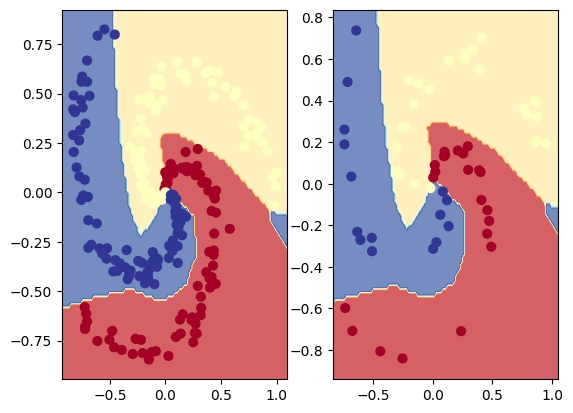

In [150]:
plt.subplot(1,2,1)
plot_decision_boundary(model1,x_train,y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model1,x_test,y_test)